In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\student_performance_dataset_100.csv")
df.head()

,study_hours,attendance,previous_marks,final_marks,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,7,84,67,87.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,86,53,71.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,96,98,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,63,99,76.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,52,40,63.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    int64  
 1   attendance      100 non-null    int64  
 2   previous_marks  100 non-null    int64  
 3   final_marks     100 non-null    float64
 4   Unnamed: 4      0 non-null      float64
 5   Unnamed: 5      0 non-null      float64
 6   Unnamed: 6      0 non-null      float64
 7   Unnamed: 7      0 non-null      float64
 8   Unnamed: 8      0 non-null      float64
 9   Unnamed: 9      0 non-null      float64
 10  Unnamed: 10     0 non-null      float64
 11  Unnamed: 11     0 non-null      float64
 12  Unnamed: 12     0 non-null      float64
 13  Unnamed: 13     0 non-null      float64
 14  Unnamed: 14     0 non-null      float64
 15  Unnamed: 15     0 non-null      float64
dtypes: float64(13), int64(3)
memory usage: 12.6 KB


In [4]:
df.isnull().sum()

study_hours         0
attendance          0
previous_marks      0
final_marks         0
Unnamed: 4        100
Unnamed: 5        100
Unnamed: 6        100
Unnamed: 7        100
Unnamed: 8        100
Unnamed: 9        100
Unnamed: 10       100
Unnamed: 11       100
Unnamed: 12       100
Unnamed: 13       100
Unnamed: 14       100
Unnamed: 15       100
dtype: int64

In [5]:
df = df.fillna(df.mean(numeric_only=True))
print(df.shape)

(100, 16)


In [6]:
X = df[["study_hours", "attendance", "previous_marks"]]
y = df["final_marks"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[68.50220871 81.40324882 97.40050927 62.2663352  85.46140723]


In [10]:
from sklearn.metrics import r2_score

print("Accuracy:", r2_score(y_test, y_pred))

Accuracy: 0.9555941107732117


In [11]:

sample = pd.DataFrame([[5, 80, 70]],
                       columns=["study_hours", "attendance", "previous_marks"])

result = model.predict(sample)

print("Predicted Marks:", result)

Predicted Marks: [77.42490958]


In [12]:
print(round(model.predict(sample)[0], 2))

77.42


In [13]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9555941107732117


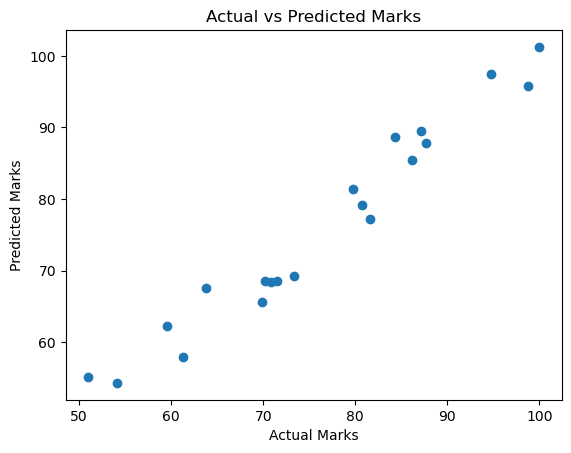

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

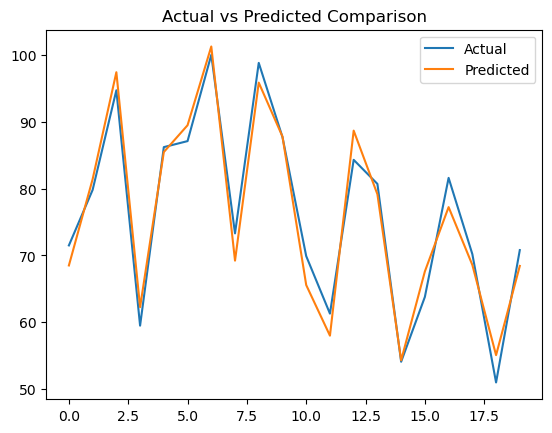

In [15]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.show()

In [16]:
import joblib

joblib.dump(model, "student_model.pkl")
print("Model saved successfully")

Model saved successfully


In [17]:
import pandas as pd

sample = pd.DataFrame([[5, 80, 70]], columns=X.columns)

result = model.predict(sample)

print("Predicted Marks:", result[0])

Predicted Marks: 77.42490957561539


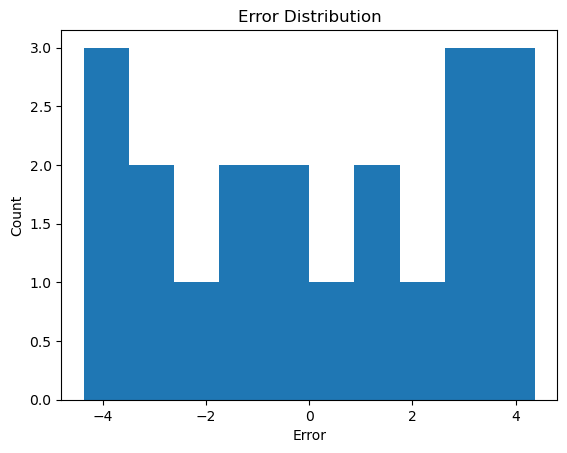

In [18]:
import numpy as np
import matplotlib.pyplot as plt

errors = y_test - y_pred

plt.hist(errors, bins=10)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

In [19]:
import os
print(os.getcwd())

c:\Users\LENOVO\Student_performance_predicter


In [21]:
import joblib

joblib.dump(model, "student_model.pkl")
print("Model saved successfully")

Model saved successfully
